In [98]:
# Import dependencies
from functools import cache
import jax
import jax.numpy as np
from memo import memo
from enum import Enum
import matplotlib.pyplot as plt

In [99]:
from enum import IntEnum

class ACTIONS(IntEnum):
    STAY = 0 
    UP = 1
    DOWN = 2
    LEFT = 3
    RIGHT = 4

ACTIONS_COORDS = np.array([
    [0, 0],   # STAY
    [0, 1],   # UP
    [0, -1],  # DOWN
    [-1, 0],  # LEFT
    [1, 0]    # RIGHT
])

In [100]:
H, W = 21, 21
STATES = np.arange(H*W)
GRID = np.array(1-plt.imread('grid.png'), dtype=int).reshape(-1)
GOALS = np.array([0, H*W-1]) # top left and bottom right
START_STATE = 231  # Middle-right area of grid (row 11, col 0)

In [101]:
@jax.jit
def step(state, action, next_state):
    """
    Transition probability: Pr(next_state | state, action)
    Returns 1.0 if taking action from state leads to next_state, else 0.0
    """
    x, y = state % W, state // W
    
    next_coords = np.array([x, y]) + ACTIONS_COORDS[action]
    next_state_candidate = (
        + 1 * np.clip(next_coords[0], 0, W - 1)
        + W * np.clip(next_coords[1], 0, H - 1)
    )
    
    return (
        + 1.0 * ((GRID[next_state_candidate] == 0) & (next_state_candidate == next_state))  # next state free, can move there
        + 1.0 * ((GRID[next_state_candidate] == 1) & (state == next_state))  # next state is wall, stay where you are
    )

In [102]:
@jax.jit
def reward(state, action, goal):
    return 1.0 * (state==goal) - 0.1 

@jax.jit
def is_terminating(s, g):
    return s == g

# discount factor
@jax.jit
def gamma():
    return 1.0

In [103]:
@cache
@memo
def Q[state: STATES, action: ACTIONS, goal: GOALS](t):
    alice: knows(state, action, goal)
    alice: assigned(location in STATES, wpp=step(state, action, location))
    alice: chooses(move in ACTIONS, to_maximize = 0.0 if t < 0 else Q[location, move, goal](t-1))
    return E[
        reward(state, action, goal)
        + (0.0 if t < 0 else 0.0 if is_terminating(state, goal) else 
        gamma() * Q[alice.location, alice.move, goal](t-1))
    ]

In [104]:
@memo 
def inv_plan[state: STATES, action: ACTIONS, goal: GOALS](t):
    observer: knows(state, action, goal)
    observer: thinks[
        alice: chooses(goal in GOALS, wpp=1), 
        alice: knows(state), 
        alice: chooses(move in ACTIONS, wpp=exp(2*Q[state, move, goal](t)))
    ]
    observer: observes [alice.move] is action 
    return observer[Pr[alice.goal == goal]]

In [105]:
# Pre-compile and test Q function
print("Pre-compiling Q function...")
Q(0)  # pre-compile

print("\nTesting Q function with t=30:")
q_vals = Q(30)
print(f"Shape: {q_vals.shape}")  # Should be (num_states, num_actions, num_goals)
print(f"Sample Q-values at START_STATE ({START_STATE}):")
print(q_vals[START_STATE, :, :])  # All actions and goals for start state

# Compute value function (max Q over actions)
v = q_vals.max(axis=1)
print(f"\nValue function shape: {v.shape}")
print(f"Value at state 0 for each goal: {v[0, :]}")
print(f"Value at state {H*W-1} (bottom-right) for each goal: {v[H*W-1, :]}")
print(f"Value at START_STATE ({START_STATE}) for each goal: {v[START_STATE, :]}")

Pre-compiling Q function...

Testing Q function with t=30:
Shape: (441, 5, 2)
Sample Q-values at START_STATE (231):
[[-0.30000007 -3.1999996 ]
 [-0.40000007 -3.1999996 ]
 [-0.20000008 -3.1999996 ]
 [-0.30000007 -3.1999996 ]
 [-0.40000007 -2.2       ]]

Value function shape: (441, 2)
Value at state 0 for each goal: [ 0.9       -3.1999996]
Value at state 440 (bottom-right) for each goal: [-3.1999996  0.9      ]
Value at START_STATE (231) for each goal: [-0.20000008 -2.2       ]


In [106]:
inv_plan(30)

Array([[[0.5       , 0.5       ],
        [0.5       , 0.5       ],
        [0.5       , 0.5       ],
        [0.5       , 0.5       ],
        [0.5       , 0.5       ]],

       [[0.5071578 , 0.4928422 ],
        [0.45726284, 0.5427372 ],
        [0.5071578 , 0.4928422 ],
        [0.55691063, 0.4430894 ],
        [0.45726284, 0.5427372 ]],

       [[0.5071578 , 0.4928422 ],
        [0.45726284, 0.5427372 ],
        [0.5071578 , 0.4928422 ],
        [0.5569106 , 0.4430894 ],
        [0.45726284, 0.5427372 ]],

       ...,

       [[0.51083034, 0.48916963],
        [0.51083034, 0.48916963],
        [0.51083034, 0.48916963],
        [0.51083034, 0.48916963],
        [0.46091196, 0.539088  ]],

       [[0.50199866, 0.4980013 ],
        [0.50199866, 0.4980013 ],
        [0.55181205, 0.448188  ],
        [0.50199866, 0.4980013 ],
        [0.45214558, 0.5478544 ]],

       [[0.5       , 0.5       ],
        [0.5       , 0.5       ],
        [0.5       , 0.5       ],
        [0.5       , 0.5 

In [107]:
# Test inverse planning function
print("Testing inverse planning function...")
print("\nPre-compiling inv_plan...")
inv_plan(0)  # pre-compile

print("\nComputing inverse plan with t=30:")
ip = inv_plan(30)
print(f"Shape: {ip.shape}")  # Should be (num_states, num_actions, num_goals)

# Test at start state with different actions
print(f"\nAt START_STATE {START_STATE} (row {START_STATE // W}, col {START_STATE % W}):")
for action_idx, action_name in enumerate(['STAY', 'UP', 'DOWN', 'LEFT', 'RIGHT']):
    probs = ip[START_STATE, action_idx, :]
    most_likely = GOALS[np.argmax(probs)]
    print(f"  {action_name}: Goal probs = {probs}, Most likely goal = {most_likely}")

Testing inverse planning function...

Pre-compiling inv_plan...

Computing inverse plan with t=30:
Shape: (441, 5, 2)

At START_STATE 231 (row 11, col 0):
  STAY: Goal probs = [0.7009545 0.2990454], Most likely goal = 0
  UP: Goal probs = [0.6574267  0.34257337], Most likely goal = 0
  DOWN: Goal probs = [0.7411295  0.25887048], Most likely goal = 0
  LEFT: Goal probs = [0.7009545 0.2990454], Most likely goal = 0
  RIGHT: Goal probs = [0.20617273 0.79382724], Most likely goal = 440


In [108]:
# Demo: Infer goal from a sequence of observed actions
# Simulate an agent moving from START_STATE toward top-left goal (state 0)
# Path goes: start at state 231 (row 11, col 0) -> navigate to state 0 (row 0, col 0)

# Define a longer sequence showing agent heading to top-left goal
observed_actions = [
    (START_STATE, ACTIONS.UP),      # Start moving up
    (210, ACTIONS.UP),              # Continue up
    (189, ACTIONS.UP),              # Continue up
    (168, ACTIONS.UP),              # Continue up
    (147, ACTIONS.UP),              # Continue up
    (126, ACTIONS.UP),              # Continue up
    (105, ACTIONS.UP),              # Continue up
    (84, ACTIONS.UP),               # Continue up
    (63, ACTIONS.UP),               # Continue up
    (42, ACTIONS.UP),               # Continue up
    (21, ACTIONS.UP),               # Continue up
    (0, ACTIONS.STAY),              # Reached goal! Stay
    (0, ACTIONS.STAY),              # Stay at goal
    (0, ACTIONS.STAY),              # Stay at goal
]

print("Inverse Planning Demo: Inferring goal from observed actions")
print("="*60)
print(f"Start state: {START_STATE} (row {START_STATE // W}, col {START_STATE % W})")
print(f"Goals: {GOALS} (state {GOALS[0]} = top-left, state {GOALS[1]} = bottom-right)")
print("="*60)

# Compute inverse plan once
t_horizon = 30
ip = inv_plan(t_horizon)

for i, (state, action) in enumerate(observed_actions):
    row, col = state // W, state % W
    print(f"\nStep {i+1}: At state {state} (row {row}, col {col}), observed action {ACTIONS(action).name}")
    
    # Extract probabilities for this state-action pair from pre-computed ip
    probs = ip[state, action, :]
    
    print(f"  Inferred goal probabilities:")
    for j, goal in enumerate(GOALS):
        goal_row, goal_col = goal // W, goal % W
        print(f"    Goal {goal} (row {goal_row}, col {goal_col}) [{['top-left', 'bottom-right'][j]}]: {probs[j]:.4f}")
    
    # Show which goal is most likely
    most_likely_goal_idx = np.argmax(probs)
    print(f"  Most likely goal: {GOALS[most_likely_goal_idx]} ({['top-left', 'bottom-right'][most_likely_goal_idx]})")

Inverse Planning Demo: Inferring goal from observed actions
Start state: 231 (row 11, col 0)
Goals: [  0 440] (state 0 = top-left, state 440 = bottom-right)

Step 1: At state 231 (row 11, col 0), observed action UP
  Inferred goal probabilities:
    Goal 0 (row 0, col 0) [top-left]: 0.6574
    Goal 440 (row 20, col 20) [bottom-right]: 0.3426
  Most likely goal: 0 (top-left)

Step 2: At state 210 (row 10, col 0), observed action UP
  Inferred goal probabilities:
    Goal 0 (row 0, col 0) [top-left]: 0.4573
    Goal 440 (row 20, col 20) [bottom-right]: 0.5427
  Most likely goal: 440 (bottom-right)

Step 3: At state 189 (row 9, col 0), observed action UP
  Inferred goal probabilities:
    Goal 0 (row 0, col 0) [top-left]: 0.4573
    Goal 440 (row 20, col 20) [bottom-right]: 0.5427
  Most likely goal: 440 (bottom-right)

Step 4: At state 168 (row 8, col 0), observed action UP
  Inferred goal probabilities:
    Goal 0 (row 0, col 0) [top-left]: 0.4573
    Goal 440 (row 20, col 20) [bottom-r

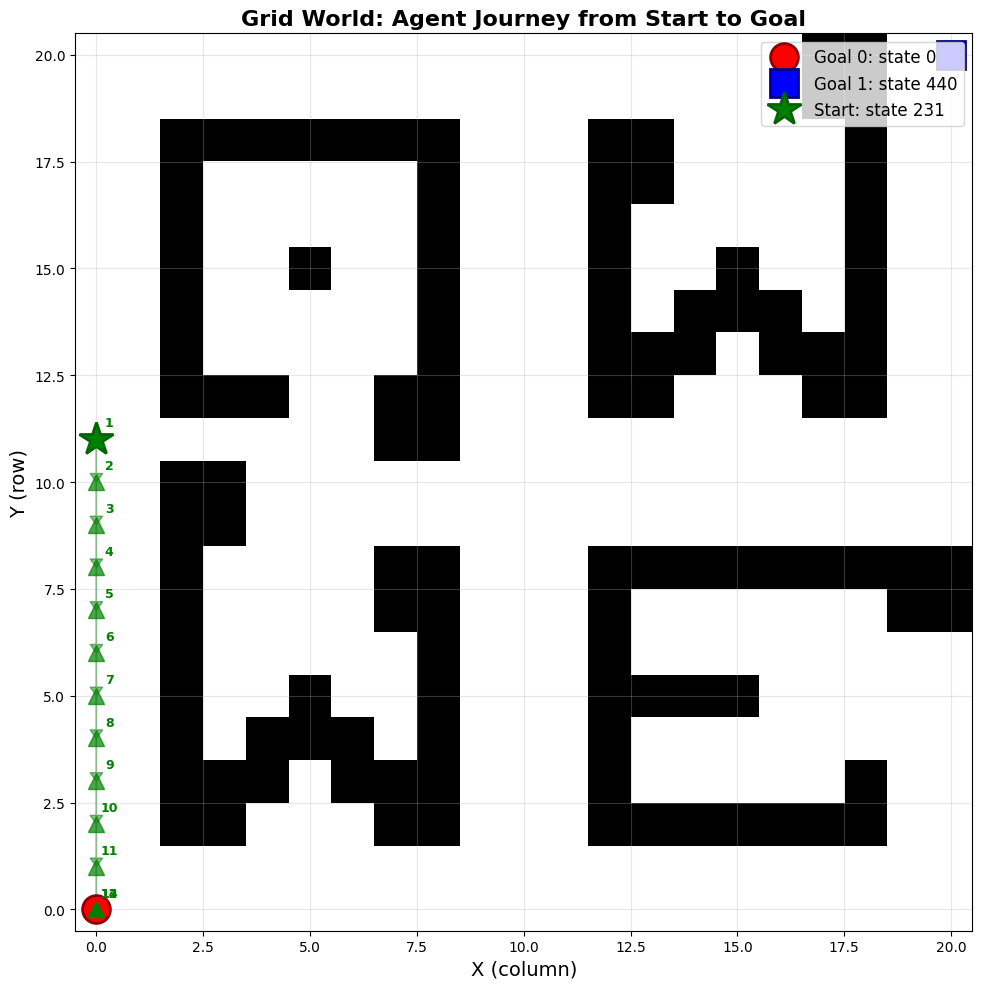

In [109]:
# Visualize the grid and goal locations with full trajectory
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Display the grid
grid_2d = GRID.reshape(H, W)
ax.imshow(grid_2d, cmap='binary', origin='lower')

# Mark the two goals
goal_0_coords = (GOALS[0] % W, GOALS[0] // W)  # top-left
goal_1_coords = (GOALS[1] % W, GOALS[1] // W)  # bottom-right

ax.plot(goal_0_coords[0], goal_0_coords[1], 'ro', markersize=20, label=f'Goal 0: state {GOALS[0]}', markeredgewidth=2, markeredgecolor='darkred')
ax.plot(goal_1_coords[0], goal_1_coords[1], 'bs', markersize=20, label=f'Goal 1: state {GOALS[1]}', markeredgewidth=2, markeredgecolor='darkblue')

# Mark the start position
start_x, start_y = START_STATE % W, START_STATE // W
ax.plot(start_x, start_y, 'g*', markersize=25, label=f'Start: state {START_STATE}', markeredgewidth=2, markeredgecolor='darkgreen')

# Mark the observed trajectory
for i, (state, action) in enumerate(observed_actions):
    x, y = state % W, state // W
    ax.plot(x, y, 'g^', markersize=12, alpha=0.7)
    ax.text(x+0.3, y+0.3, str(i+1), ha='center', fontsize=9, color='green', fontweight='bold')

# Draw arrows showing the path
for i in range(len(observed_actions) - 1):
    state1, _ = observed_actions[i]
    state2, _ = observed_actions[i + 1]
    x1, y1 = state1 % W, state1 // W
    x2, y2 = state2 % W, state2 // W
    if state1 != state2:  # Only draw arrow if actually moving
        ax.arrow(x1, y1, x2-x1, y2-y1, head_width=0.3, head_length=0.2, 
                fc='green', ec='green', alpha=0.5, length_includes_head=True)

ax.set_title('Grid World: Agent Journey from Start to Goal', fontsize=16, fontweight='bold')
ax.set_xlabel('X (column)', fontsize=14)
ax.set_ylabel('Y (row)', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

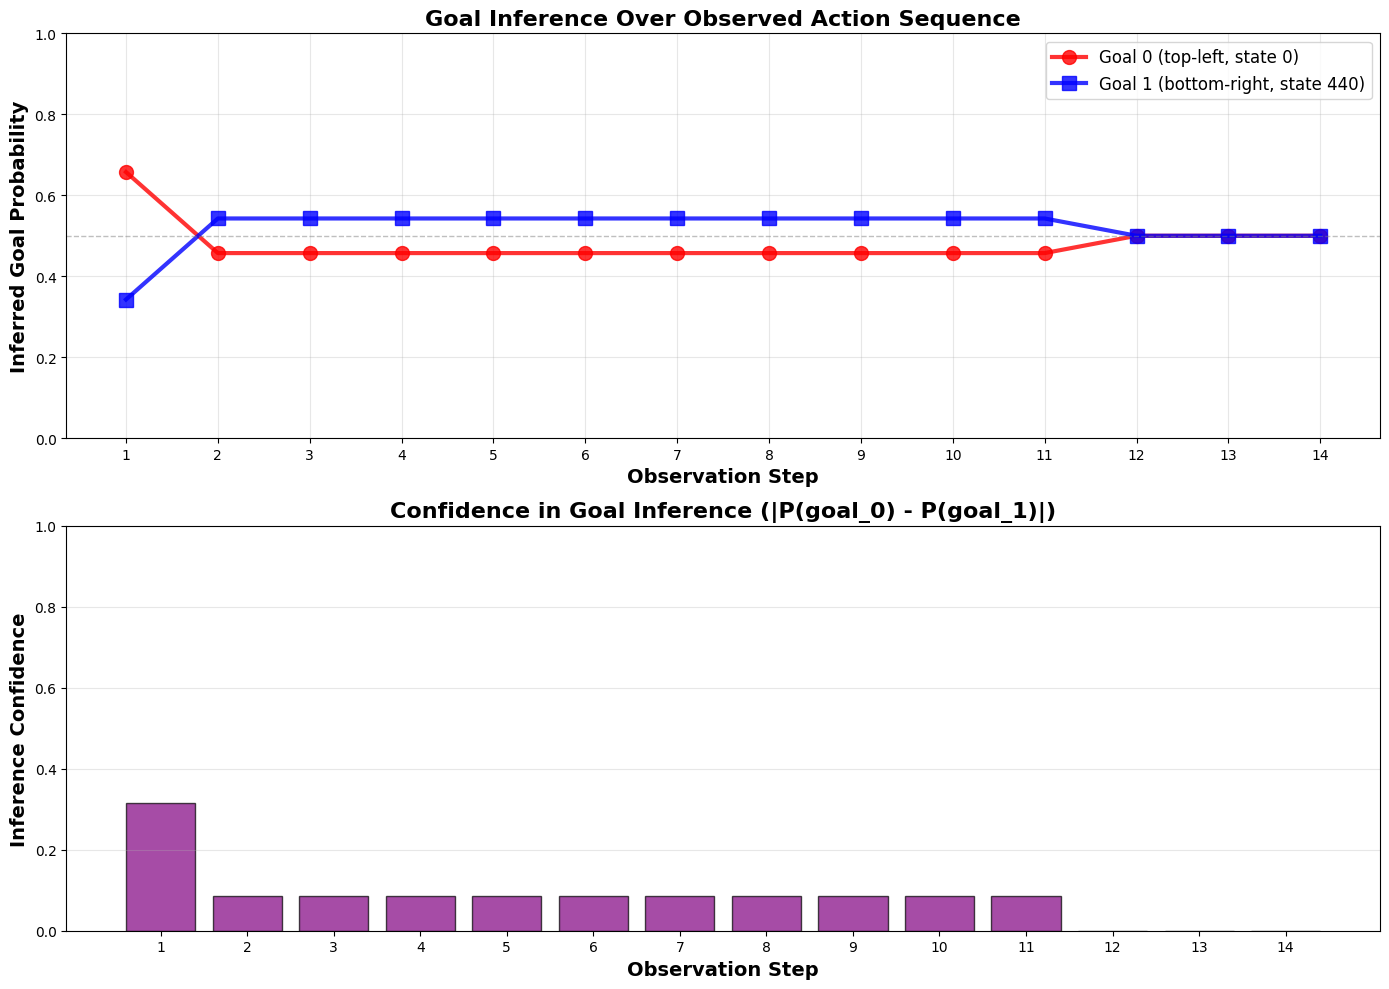


Goal Inference Summary:
Initial inference (step 1):
  Goal 0 (top-left): 0.6574
  Goal 1 (bottom-right): 0.3426
  Confidence: 0.3149

Final inference (step 14):
  Goal 0 (top-left): 0.5000
  Goal 1 (bottom-right): 0.5000
  Confidence: 0.0000

Agent reached goal 0 and stayed there!


In [110]:
# Plot goal probabilities over the sequence of observations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Collect goal probabilities for each observation from pre-computed ip
goal_0_probs = []
goal_1_probs = []

for state, action in observed_actions:
    probs = ip[state, action, :]
    goal_0_probs.append(float(probs[0]))
    goal_1_probs.append(float(probs[1]))

steps = np.arange(1, len(observed_actions) + 1)

# Top plot: Goal probabilities over time
ax1.plot(steps, goal_0_probs, 'ro-', linewidth=3, markersize=10, label=f'Goal 0 (top-left, state {GOALS[0]})', alpha=0.8)
ax1.plot(steps, goal_1_probs, 'bs-', linewidth=3, markersize=10, label=f'Goal 1 (bottom-right, state {GOALS[1]})', alpha=0.8)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Observation Step', fontsize=14, fontweight='bold')
ax1.set_ylabel('Inferred Goal Probability', fontsize=14, fontweight='bold')
ax1.set_title('Goal Inference Over Observed Action Sequence', fontsize=16, fontweight='bold')
ax1.set_ylim([0, 1])
ax1.set_xticks(steps)
ax1.legend(fontsize=12, loc='best')
ax1.grid(True, alpha=0.3)

# Bottom plot: Confidence (difference between top two goals)
confidence = [abs(goal_0_probs[i] - goal_1_probs[i]) for i in range(len(steps))]
ax2.bar(steps, confidence, color='purple', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Observation Step', fontsize=14, fontweight='bold')
ax2.set_ylabel('Inference Confidence', fontsize=14, fontweight='bold')
ax2.set_title('Confidence in Goal Inference (|P(goal_0) - P(goal_1)|)', fontsize=16, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.set_xticks(steps)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nGoal Inference Summary:")
print(f"{'='*60}")
print(f"Initial inference (step 1):")
print(f"  Goal 0 (top-left): {goal_0_probs[0]:.4f}")
print(f"  Goal 1 (bottom-right): {goal_1_probs[0]:.4f}")
print(f"  Confidence: {confidence[0]:.4f}")
print(f"\nFinal inference (step {len(observed_actions)}):")
print(f"  Goal 0 (top-left): {goal_0_probs[-1]:.4f}")
print(f"  Goal 1 (bottom-right): {goal_1_probs[-1]:.4f}")
print(f"  Confidence: {confidence[-1]:.4f}")
print(f"\nAgent reached goal 0 and stayed there!")
print(f"{'='*60}")

In [111]:
# Sanity checks to verify results make sense

print("SANITY CHECKS")
print("="*60)

# Check 1: Q-values should be higher for goals that are closer
print("\n1. Q-values at state 0 (top-left corner):")
print("   - Goal 0 is AT state 0, Goal 1 is at state 440 (far away)")
q_vals = Q(30)
v = q_vals.max(axis=1)
v_state_0 = v[0, :]
print(f"   Value at state 0 for Goal 0 (should be high): {v_state_0[0]:.3f}")
print(f"   Value at state 0 for Goal 1 (should be low): {v_state_0[1]:.3f}")
print(f"   ✓ Makes sense!" if v_state_0[0] > v_state_0[1] else "   ✗ Problem!")

# Check 2: Q-values at the goal state should be maximum
print(f"\n2. Q-values at state 440 (bottom-right corner):")
v_state_440 = v[H*W-1, :]
print(f"   Value at state 440 for Goal 0 (far away): {v_state_440[0]:.3f}")
print(f"   Value at state 440 for Goal 1 (should be high): {v_state_440[1]:.3f}")
print(f"   ✓ Makes sense!" if v_state_440[1] > v_state_440[0] else "   ✗ Problem!")

# Check 3: Q-values at start state
print(f"\n3. Q-values at START_STATE {START_STATE} (row {START_STATE // W}, col {START_STATE % W}):")
v_start = v[START_STATE, :]
print(f"   Value for Goal 0 (top-left): {v_start[0]:.3f}")
print(f"   Value for Goal 1 (bottom-right): {v_start[1]:.3f}")
print(f"   Goal 0 is closer, so should have higher value: {'✓' if v_start[0] > v_start[1] else '✗'}")

# Check 4: Agent at goal should have high probability of staying
print(f"\n4. Inverse planning at goal state 0, action STAY:")
ip = inv_plan(30)
ip_at_goal = ip[0, ACTIONS.STAY, :]
print(f"   P(Goal 0 | state=0, action=STAY): {ip_at_goal[0]:.3f}")
print(f"   P(Goal 1 | state=0, action=STAY): {ip_at_goal[1]:.3f}")
# Note: This might not always be > 0.5 due to Boltzmann rationality

# Check 5: Actions toward a goal should have higher probability for that goal
print(f"\n5. Inverse planning at START_STATE {START_STATE}:")
print(f"   Action UP moves toward Goal 0 (top-left):")
ip_up = ip[START_STATE, ACTIONS.UP, :]
print(f"     P(Goal 0 | UP): {ip_up[0]:.3f}")
print(f"     P(Goal 1 | UP): {ip_up[1]:.3f}")
print(f"   Action DOWN moves toward Goal 1 (bottom-right):")
ip_down = ip[START_STATE, ACTIONS.DOWN, :]
print(f"     P(Goal 0 | DOWN): {ip_down[0]:.3f}")
print(f"     P(Goal 1 | DOWN): {ip_down[1]:.3f}")
print(f"   ✓ Makes sense!" if ip_up[0] > ip_up[1] and ip_down[1] > ip_down[0] else "   ✗ Problem!")

# Check 6: Probabilities should sum to 1
print(f"\n6. Probability normalization:")
print(f"   Sum at START_STATE, action UP: {ip[START_STATE, ACTIONS.UP, :].sum():.3f}")
print(f"   Sum at state 0, action STAY: {ip[0, ACTIONS.STAY, :].sum():.3f}")
all_normalized = np.allclose(ip.sum(axis=2), 1.0)
print(f"   All probabilities sum to 1: {all_normalized}")
print(f"   ✓ Makes sense!" if all_normalized else "   ✗ Problem!")

print("\n" + "="*60)

SANITY CHECKS

1. Q-values at state 0 (top-left corner):
   - Goal 0 is AT state 0, Goal 1 is at state 440 (far away)
   Value at state 0 for Goal 0 (should be high): 0.900
   Value at state 0 for Goal 1 (should be low): -3.200
   ✓ Makes sense!

2. Q-values at state 440 (bottom-right corner):
   Value at state 440 for Goal 0 (far away): -3.200
   Value at state 440 for Goal 1 (should be high): 0.900
   ✓ Makes sense!

3. Q-values at START_STATE 231 (row 11, col 0):
   Value for Goal 0 (top-left): -0.200
   Value for Goal 1 (bottom-right): -2.200
   Goal 0 is closer, so should have higher value: ✓

4. Inverse planning at goal state 0, action STAY:
   P(Goal 0 | state=0, action=STAY): 0.500
   P(Goal 1 | state=0, action=STAY): 0.500

5. Inverse planning at START_STATE 231:
   Action UP moves toward Goal 0 (top-left):
     P(Goal 0 | UP): 0.657
     P(Goal 1 | UP): 0.343
   Action DOWN moves toward Goal 1 (bottom-right):
     P(Goal 0 | DOWN): 0.741
     P(Goal 1 | DOWN): 0.259
   ✗ Prob